# Polish Apartment Price Prediction — Feature Study
**Data:** 36,318 listings scraped from Otodom.pl — 17 Polish cities, April 2026

**Research questions:**
1. Do scraped detail features (year built, condition, building type) improve predictions?
2. Is more data with fewer features better than less data with richer features?
3. Does selective null handling (drop key features, impute weak ones) beat full imputation or full drop?
4. Which features matter most?

**Variants:**
| Variant | Rows | Features | Null strategy |
|---|---|---|---|
| A | ~35k | base only | — |
| B1 | ~30k | base + details | all imputed |
| B2 | ~14k | base + details | all null rows dropped |
| Final | ~25k | base + details | drop where rok_budowy/stan_wykonczenia null, impute rest |
| C1 | ~15k | base + details | imputed, stratified half |
| C2 | ~7k | base + details | dropped, stratified half |
| D | ~15k | base only | — (same rows as C1) |
| E | ~30k | top 10 SHAP features | imputed |

**Null strategy rationale (Final):**
rok_budowy (#3 SHAP) and stan_wykonczenia (#6 SHAP) are highly predictive —
imputing them with mode/median would introduce noise. Columns outside top 10 SHAP
(ogrzewanie, rodzaj_zabudowy, forma_wlasnosci, okna, liczba_pieter) are imputed
to preserve row count.

**Encoding:** target encoding for city/neighborhood (fit on train only, anti-leakage),
one-hot for low-cardinality categoricals, boolean flags cast to int
**Model:** XGBoost regression, log1p target, 80/20 split, SEED=17

## Imports

In [1]:
from __future__ import annotations

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBRegressor
import shap

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:.2f}".format)
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})

SEED = 17
np.random.seed(SEED)
print("imports ok")

imports ok


## 1. Data Loading

In [2]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

DRIVE_DIR   = Path("/content/drive/MyDrive/housing-scraper/data/snapshots")
MERGED_PATH = DRIVE_DIR / "2026-04_merged_36318rows.csv"
DETAILS_PATH = DRIVE_DIR / "otodom_details.csv"

df_main = pd.read_csv(MERGED_PATH, encoding="utf-8-sig")
df_details = pd.read_csv(DETAILS_PATH, encoding="utf-8-sig", low_memory=False)

print(f"Main     : {df_main.shape}")
print(f"Details  : {df_details.shape}")
print()
print("Main columns    :", df_main.columns.tolist())
print("Details columns :", df_details.columns.tolist())

Mounted at /content/drive
Main     : (36318, 10)
Details  : (35225, 32)

Main columns    : ['city', 'price', 'price_per_m2', 'area_m2', 'rooms', 'floor', 'neighborhood', 'sub_neighborhood', 'is_private_owner', 'url']
Details columns : ['rynek', 'rodzaj_zabudowy', 'liczba_pieter', 'ogrzewanie', 'rok_budowy', 'stan_wykonczenia', 'czynsz', 'forma_wlasnosci', 'dostepne_od', 'winda', 'balkon', 'taras', 'ogrodek', 'piwnica', 'garaz', 'dwupoziomowe', 'oddzielna_kuchnia', 'klimatyzacja', 'umeblowane', 'teren_zamkniety', 'monitoring', 'domofon', 'okna_antywlamaniowe', 'internet', 'pralka', 'zmywarka', 'lodowka', 'kuchenka', 'piekarnik', 'telewizor', 'url', 'okna']


### 1.1 Merge & basic stats

In [3]:
df = df_main.merge(df_details, on="url", how="left")

df["has_details"] = df["rok_budowy"].notna()

print(f"After merge: {df.shape}")
print(f"Rows with details:    {df['has_details'].sum():,} ({df['has_details'].mean()*100:.1f}%)")
print(f"Rows without details: {(~df['has_details']).sum():,}")
print()
print("Null % per column:")
print(df.isna().mean().mul(100).round(1).sort_values(ascending=False).to_string())

After merge: (36318, 42)
Rows with details:    30,548 (84.1%)
Rows without details: 5,770

Null % per column:
dostepne_od           48.20
sub_neighborhood      38.20
okna                  35.70
czynsz                34.00
ogrzewanie            19.90
rodzaj_zabudowy       18.00
forma_wlasnosci       16.60
stan_wykonczenia      16.10
rok_budowy            15.90
liczba_pieter          9.00
floor                  5.10
oddzielna_kuchnia      3.10
umeblowane             3.10
klimatyzacja           3.10
monitoring             3.10
domofon                3.10
okna_antywlamaniowe    3.10
neighborhood           3.10
dwupoziomowe           3.10
rynek                  3.10
balkon                 3.10
winda                  3.10
ogrodek                3.10
piwnica                3.10
garaz                  3.10
taras                  3.10
internet               3.10
pralka                 3.10
lodowka                3.10
zmywarka               3.10
kuchenka               3.10
piekarnik             

## 2. Cleaning & Column Selection

Drop columns with >30% nulls or irrelevant to sale price.  
Define base features and detail features used across all variants.

In [4]:
DROP_ALWAYS = [
    "sub_neighborhood",  # 38% null, granularity already captured by neighborhood
    "dostepne_od",       # 48% null, availability date irrelevant to purchase price
    "czynsz",            # 34% null, admin fee irrelevant to purchase price
    "price_per_m2",      # derived from price/area — would leak target
    "url",               # identifier only
]

DROP_AGD = ["pralka", "zmywarka", "lodowka", "kuchenka", "piekarnik", "telewizor", "internet", "umeblowane"]

df = df.drop(columns=DROP_ALWAYS + DROP_AGD, errors="ignore")

BASE_FEATURES    = ["area_m2", "rooms", "floor", "is_private_owner"]
BASE_CATEGORICAL = ["city", "neighborhood"]

DETAIL_NUMERIC     = ["rok_budowy", "liczba_pieter"]
DETAIL_CATEGORICAL = ["rodzaj_zabudowy", "ogrzewanie", "stan_wykonczenia", "forma_wlasnosci", "rynek", "okna"]
DETAIL_BOOL        = ["winda", "balkon", "taras", "ogrodek", "piwnica", "garaz",
                      "dwupoziomowe", "oddzielna_kuchnia", "klimatyzacja",
                      "teren_zamkniety", "monitoring", "domofon", "okna_antywlamaniowe"]

TARGET = "log_price"

print(f"Remaining columns : {df.shape[1]}")
print(f"Base features     : {BASE_FEATURES + BASE_CATEGORICAL}")
print(f"Detail numeric    : {DETAIL_NUMERIC}")
print(f"Detail categorical: {DETAIL_CATEGORICAL}")
print(f"Detail bool flags : {DETAIL_BOOL}")

Remaining columns : 29
Base features     : ['area_m2', 'rooms', 'floor', 'is_private_owner', 'city', 'neighborhood']
Detail numeric    : ['rok_budowy', 'liczba_pieter']
Detail categorical: ['rodzaj_zabudowy', 'ogrzewanie', 'stan_wykonczenia', 'forma_wlasnosci', 'rynek', 'okna']
Detail bool flags : ['winda', 'balkon', 'taras', 'ogrodek', 'piwnica', 'garaz', 'dwupoziomowe', 'oddzielna_kuchnia', 'klimatyzacja', 'teren_zamkniety', 'monitoring', 'domofon', 'okna_antywlamaniowe']


## 3. Price Cleaning & Target

In [5]:
PRICE_MIN    = 50_000
PRICE_MAX    = 5_000_000
AREA_MIN     = 15.0
AREA_MAX     = 250.0
PPM2_MAX     = 40_000.0

before = len(df)
df = df.dropna(subset=["price", "area_m2"])
df = df[df["price"].between(PRICE_MIN, PRICE_MAX)]
df = df[df["area_m2"].between(AREA_MIN, AREA_MAX)]
df["price_per_m2_clean"] = df["price"] / df["area_m2"]
df = df[df["price_per_m2_clean"] <= PPM2_MAX].drop(columns="price_per_m2_clean")
df["log_price"] = np.log1p(df["price"])
df = df.reset_index(drop=True)

print(f"Rows before cleaning : {before}")
print(f"Rows after cleaning  : {len(df)}  (removed {before - len(df)})")
print()
print(f"price     skew: {df['price'].skew():.2f}")
print(f"log_price skew: {df['log_price'].skew():.2f}")

Rows before cleaning : 36318
Rows after cleaning  : 35543  (removed 775)

price     skew: 2.96
log_price skew: 0.51


## 4. Exploratory Data Analysis
### 4.1 Price distribution

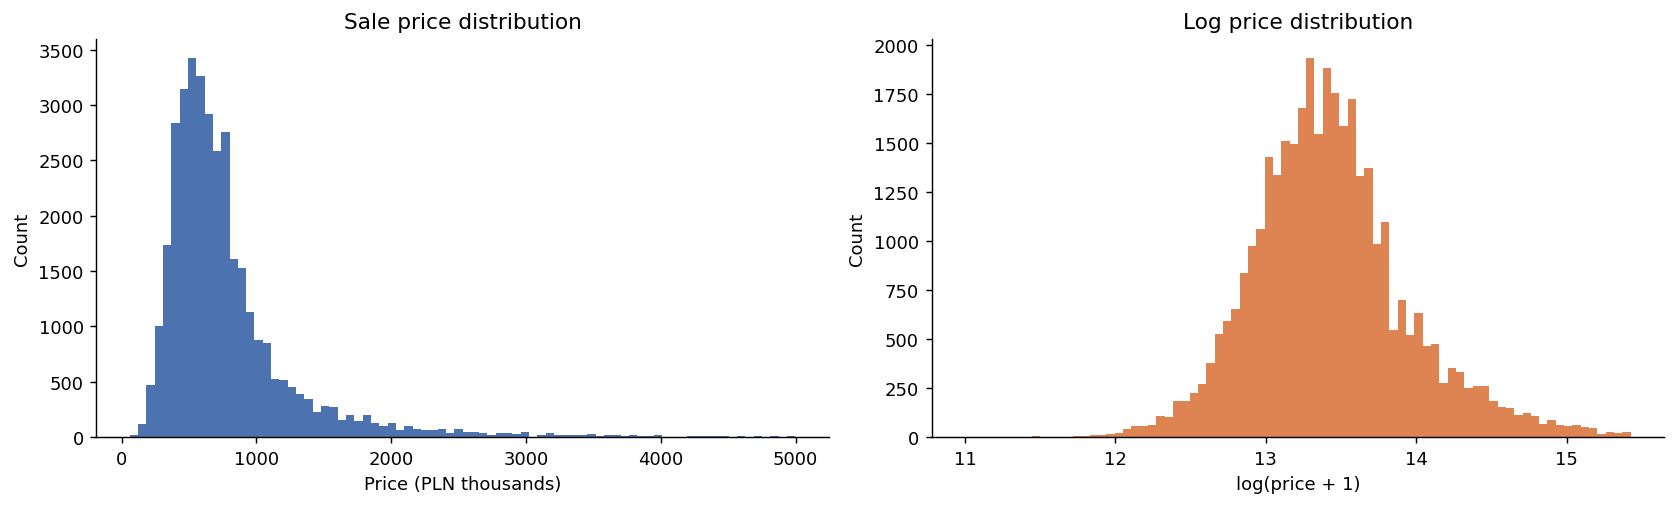

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df["price"] / 1_000, bins=80, color="#4C72B0", edgecolor="none")
axes[0].set_xlabel("Price (PLN thousands)")
axes[0].set_ylabel("Count")
axes[0].set_title("Sale price distribution")

axes[1].hist(df["log_price"], bins=80, color="#DD8452", edgecolor="none")
axes[1].set_xlabel("log(price + 1)")
axes[1].set_ylabel("Count")
axes[1].set_title("Log price distribution")

plt.tight_layout()
plt.show()

### 4.2 Median price per m² by city

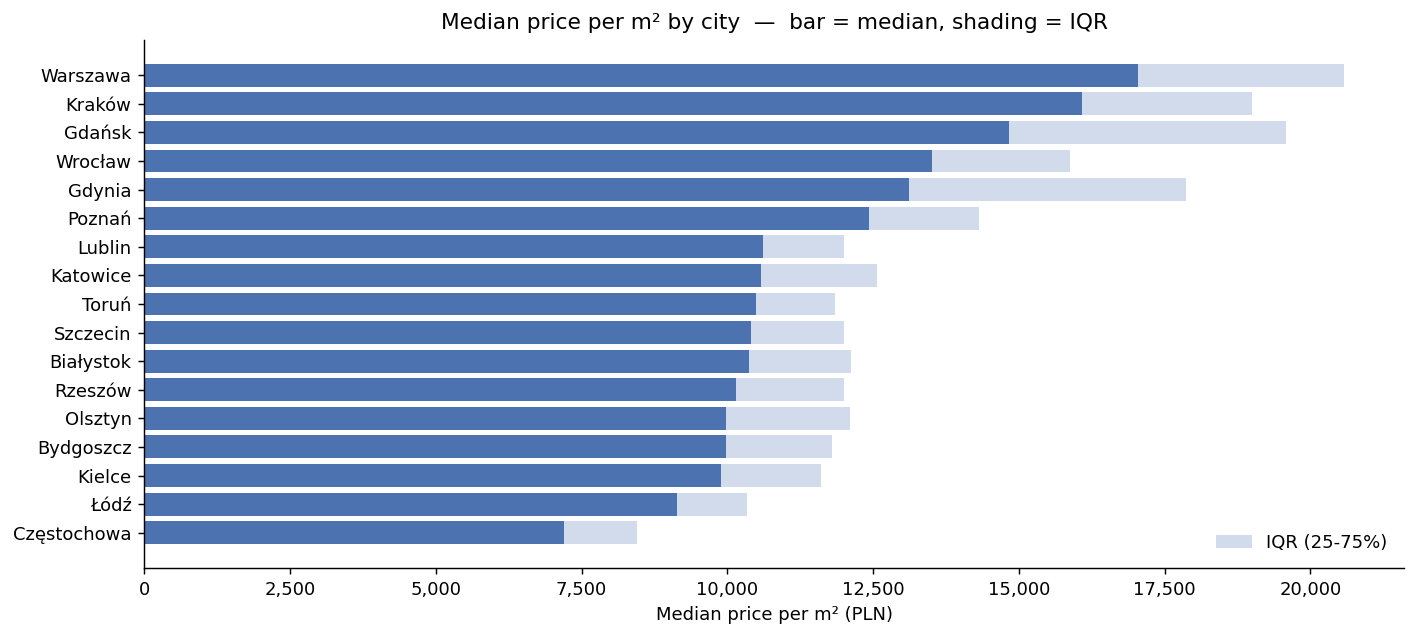

       city   median      q25      q75  count
   Warszawa 17039.95 14449.99 20575.52   7708
     Kraków 16078.43 14064.68 19000.00   4325
     Gdańsk 14823.53 11937.84 19572.76   2088
    Wrocław 13510.09 11583.33 15872.83   2530
     Gdynia 13113.25 10583.08 17861.88   1502
     Poznań 12428.08 11026.02 14315.08   2365
     Lublin 10616.84  9400.00 11996.08   1748
   Katowice 10571.91  8208.96 12564.77   1289
      Toruń 10499.75  8952.08 11854.76    202
   Szczecin 10400.00  8712.87 12004.45   1709
  Białystok 10377.21  8708.46 12118.91   1194
    Rzeszów 10155.69  8648.98 12009.45   2130
    Olsztyn  9985.71  8592.72 12102.28    477
  Bydgoszcz  9974.56  8186.20 11796.46   1396
     Kielce  9900.00  8213.88 11600.00    823
       Łódź  9145.64  7848.10 10344.68   2899
Częstochowa  7198.40  6102.04  8456.03   1158


In [7]:
city_stats = (
    df.assign(ppm2=df["price"] / df["area_m2"])
    .groupby("city")["ppm2"]
    .agg(median="median", q25=lambda x: x.quantile(0.25), q75=lambda x: x.quantile(0.75), count="count")
    .sort_values("median", ascending=False)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(11, 5))
ax.barh(city_stats["city"], city_stats["median"], color="#4C72B0", zorder=2)
ax.barh(
    city_stats["city"],
    city_stats["q75"] - city_stats["q25"],
    left=city_stats["q25"],
    color="#4C72B0", alpha=0.25, zorder=1, label="IQR (25-75%)",
)
ax.set_xlabel("Median price per m² (PLN)")
ax.set_title("Median price per m² by city  —  bar = median, shading = IQR")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.legend(frameon=False)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(city_stats[["city", "median", "q25", "q75", "count"]].to_string(index=False))

## 5. Detail feature audit

In [8]:
# Only columns that survived DROP_ALWAYS + DROP_AGD in cell 8
detail_cols = [
    "rok_budowy", "rodzaj_zabudowy", "ogrzewanie", "stan_wykonczenia",
    "forma_wlasnosci", "liczba_pieter", "okna", "rynek",
    "winda", "balkon", "taras", "ogrodek", "piwnica", "garaz",
    "dwupoziomowe", "oddzielna_kuchnia", "klimatyzacja",
    "teren_zamkniety", "monitoring", "domofon", "okna_antywlamaniowe",
]

df_detail = df[df["has_details"]].copy()

null_rates = (
    df_detail[detail_cols]
    .isnull()
    .mean()
    .sort_values(ascending=False)
    .rename("null_rate")
    .to_frame()
)
null_rates["filled_n"] = df_detail[detail_cols].notna().sum().values

print(f"Rows with details: {len(df_detail):,}\n")
print(null_rates.to_string(float_format="{:.1%}".format))

Rows with details: 29,871

                     null_rate  filled_n
okna                     32.7%     29871
ogrzewanie               14.9%     25731
rodzaj_zabudowy          13.9%     25410
forma_wlasnosci          12.1%     26305
stan_wykonczenia         11.9%     26252
liczba_pieter             5.2%     28332
rok_budowy                0.0%     20105
rynek                     0.0%     29871
winda                     0.0%     29871
balkon                    0.0%     29871
taras                     0.0%     29871
ogrodek                   0.0%     29871
piwnica                   0.0%     29871
garaz                     0.0%     29871
dwupoziomowe              0.0%     29871
oddzielna_kuchnia         0.0%     29871
klimatyzacja              0.0%     29871
teren_zamkniety           0.0%     29871
monitoring                0.0%     29871
domofon                   0.0%     29871
okna_antywlamaniowe       0.0%     29871


## 6. Numeric correlations with price

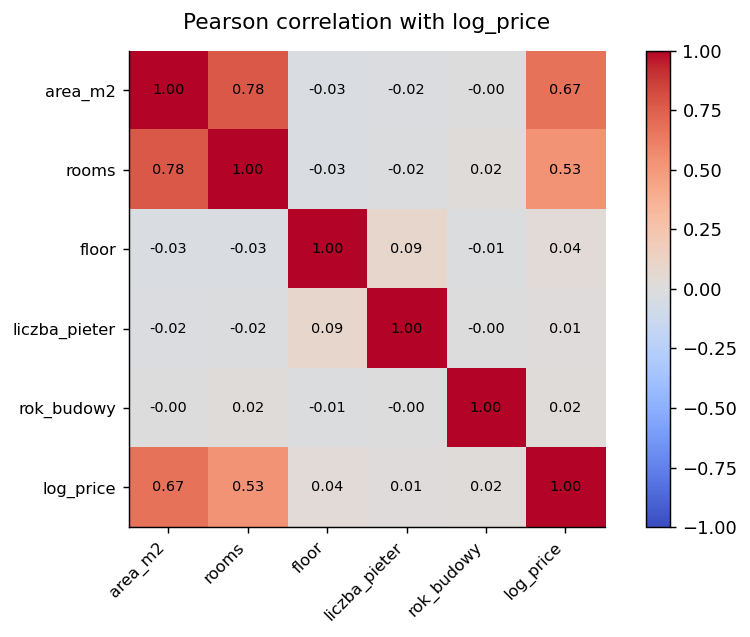


Correlation with log_price (sorted):
area_m2         0.673
rooms           0.531
floor           0.038
rok_budowy      0.016
liczba_pieter   0.014


In [9]:
numeric_cols = [
    "area_m2", "rooms", "floor", "liczba_pieter", "rok_budowy",
    "log_price",
]

corr = df[numeric_cols].corr(method="pearson")

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="coolwarm")
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(numeric_cols)))
ax.set_yticks(range(len(numeric_cols)))
ax.set_xticklabels(numeric_cols, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(numeric_cols, fontsize=9)
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
ax.set_title("Pearson correlation with log_price", pad=12)
plt.tight_layout()
plt.show()

print("\nCorrelation with log_price (sorted):")
print(corr["log_price"].drop("log_price").sort_values(ascending=False).to_string(float_format="{:.3f}".format))

## 7. Categorical detail distributions

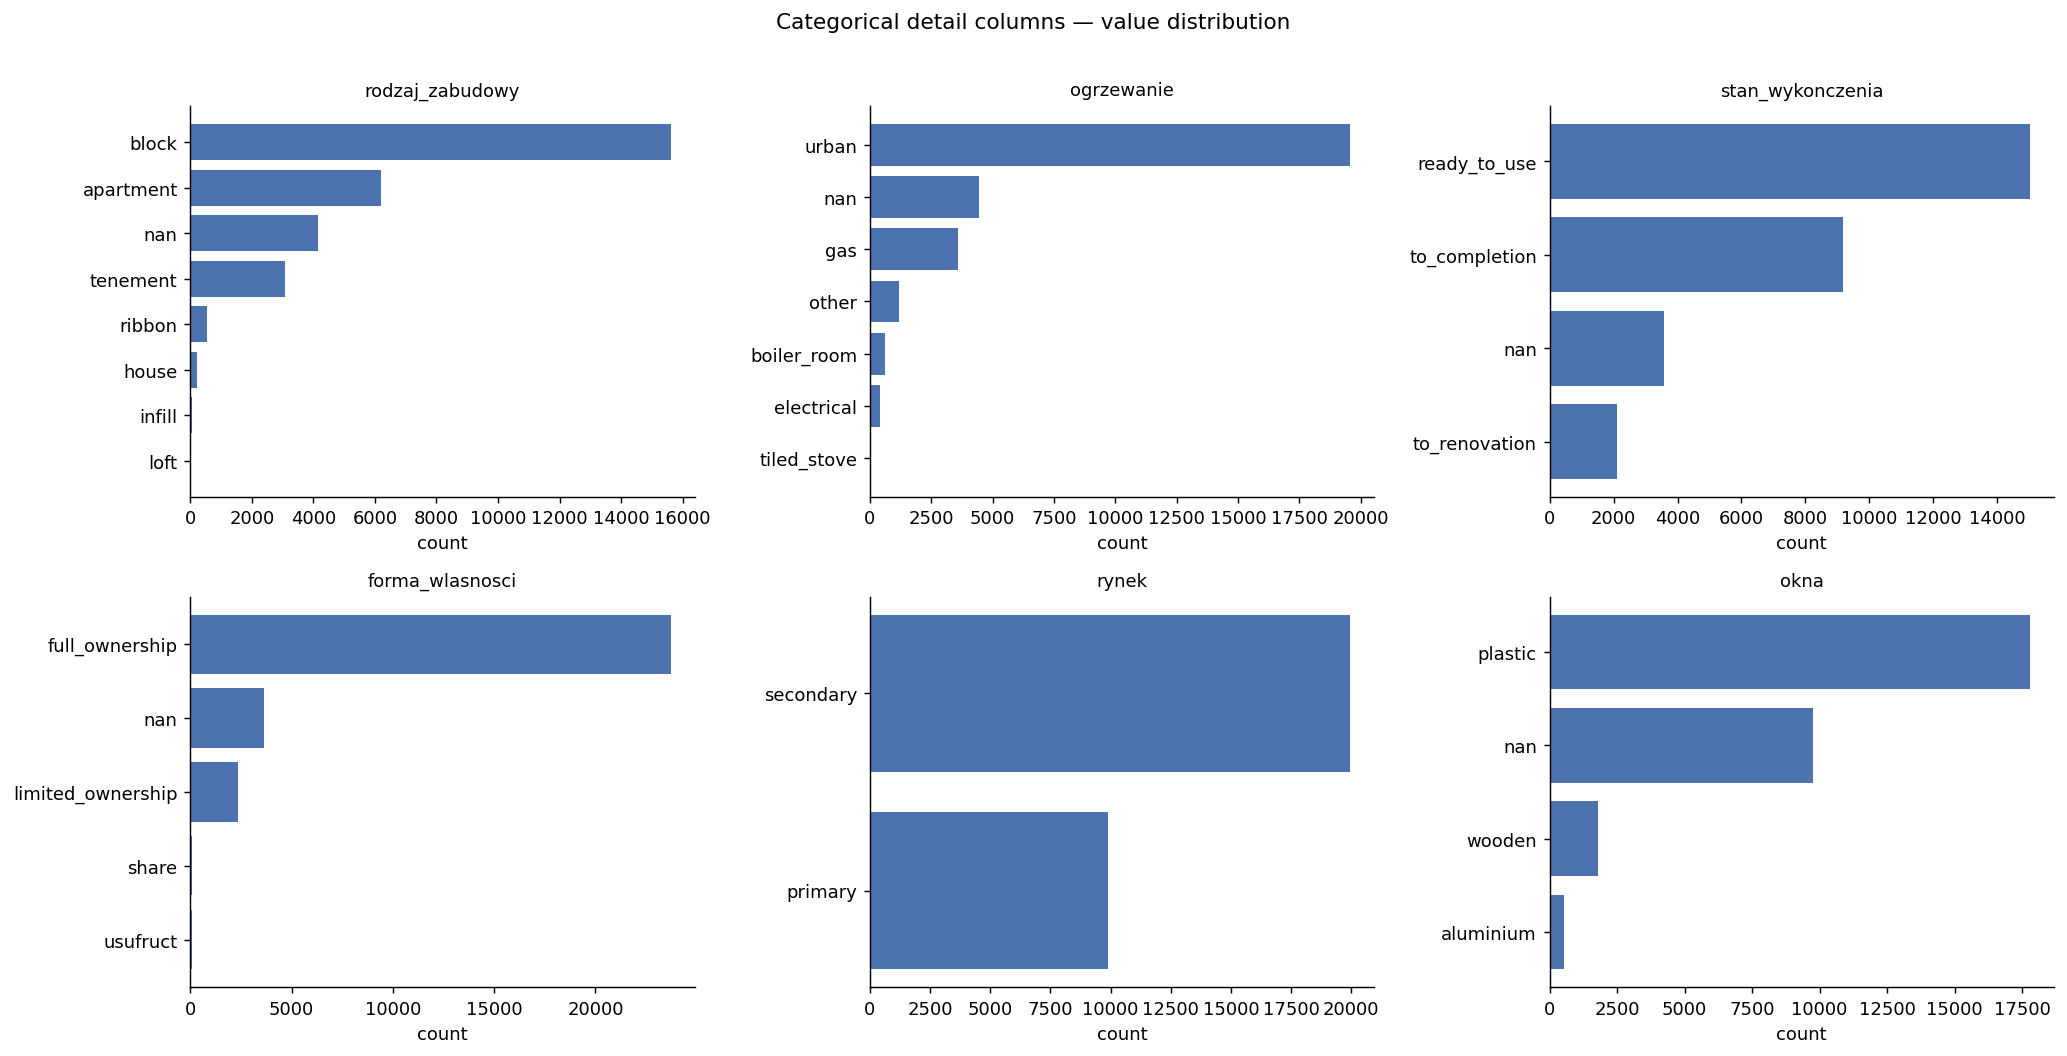

In [10]:
cat_detail_cols = [
    "rodzaj_zabudowy", "ogrzewanie", "stan_wykonczenia",
    "forma_wlasnosci", "rynek", "okna",
]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for ax, col in zip(axes, cat_detail_cols):
    counts = df_detail[col].value_counts(dropna=False).head(10)
    counts.index = counts.index.astype(str).str[:25]
    ax.barh(counts.index[::-1], counts.values[::-1], color="#4C72B0")
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("count")
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

plt.suptitle("Categorical detail columns — value distribution", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## 8. Boolean feature prevalence

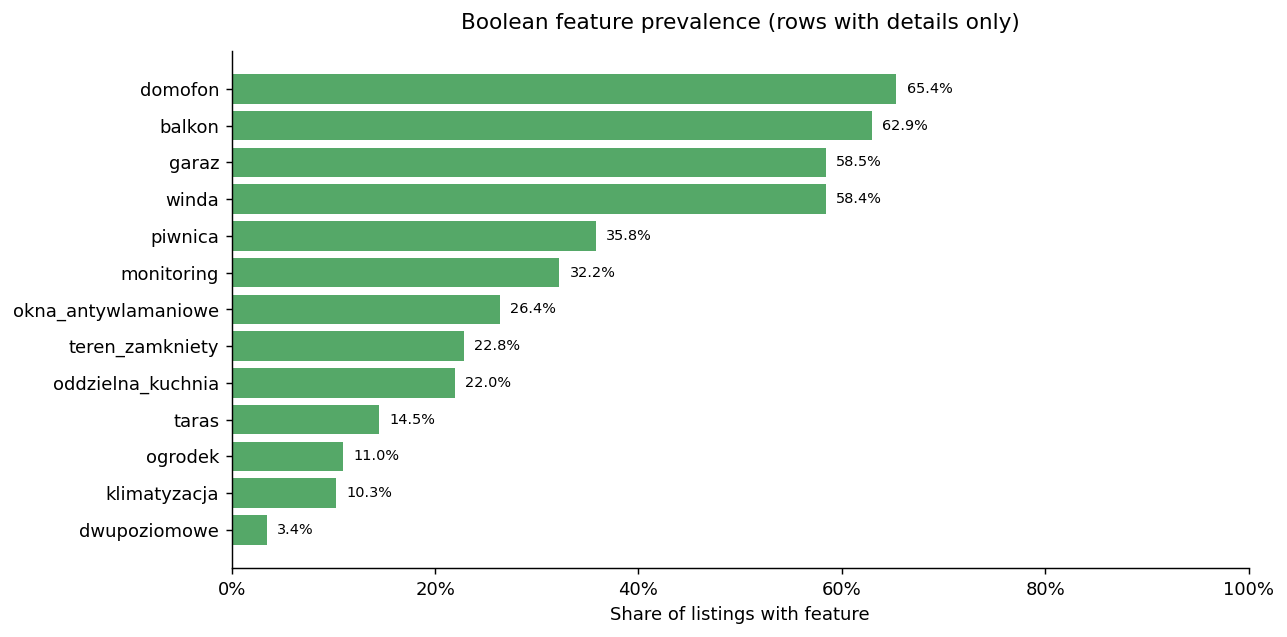

In [11]:
bool_cols = [
    "winda", "balkon", "taras", "ogrodek", "piwnica", "garaz",
    "dwupoziomowe", "oddzielna_kuchnia", "klimatyzacja",
    "teren_zamkniety", "monitoring", "domofon", "okna_antywlamaniowe",
]

prevalence = (
    df_detail[bool_cols]
    .apply(lambda s: s.map({True: 1, False: 0, "True": 1, "False": 0}).mean())
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(prevalence.index[::-1], prevalence.values[::-1], color="#55A868")
ax.set_xlabel("Share of listings with feature")
ax.set_xlim(0, 1)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
for bar, val in zip(bars, prevalence.values[::-1]):
    ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
            f"{val:.1%}", va="center", fontsize=8)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.set_title("Boolean feature prevalence (rows with details only)", pad=12)
plt.tight_layout()
plt.show()

## 9. Feature Engineering

In [12]:
# ------------------------------------------------------------------
# Feature engineering helpers
# ------------------------------------------------------------------

def target_encode(train_df: pd.DataFrame, val_df: pd.DataFrame,
                  col: str, target: str) -> tuple[pd.Series, pd.Series]:
    """Fit target encoding on train, apply to val. Returns encoded series."""
    means = train_df.groupby(col)[target].mean()
    global_mean = train_df[target].mean()
    train_enc = train_df[col].map(means).fillna(global_mean)
    val_enc   = val_df[col].map(means).fillna(global_mean)
    return train_enc, val_enc


def build_features(train_df: pd.DataFrame, val_df: pd.DataFrame,
                   use_details: bool = False) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Build X_train / X_val for a given variant.
    Target encoding for city + neighborhood (fit on train only).
    One-hot for low-cardinality categoricals (if use_details=True).
    Boolean flags cast to int.
    """
    result = {}

    for split, df_ in [("train", train_df), ("val", val_df)]:
        X = pd.DataFrame(index=df_.index)

        # Base numeric
        X["area_m2"]         = df_["area_m2"]
        X["rooms"]           = df_["rooms"].fillna(df_["rooms"].median())
        X["floor"]           = df_["floor"].fillna(df_["floor"].median())
        X["is_private_owner"] = df_["is_private_owner"].astype(int)

        result[split] = X

    # Target encoding — fit on train only
    for col, new_col in [("city", "city_enc"), ("neighborhood", "neighborhood_enc")]:
        tr_enc, va_enc = target_encode(train_df, val_df, col, TARGET)
        result["train"][new_col] = tr_enc.values
        result["val"][new_col]   = va_enc.values

    if use_details:
        # Impute detail numerics with train medians
        for col in DETAIL_NUMERIC:
            med = train_df[col].median()
            result["train"][col] = train_df[col].fillna(med).values
            result["val"][col]   = val_df[col].fillna(med).values

        # One-hot encode categoricals — fit on train only
        for col in DETAIL_CATEGORICAL:
            mode_val = train_df[col].mode()[0]
            tr_filled = train_df[col].fillna(mode_val)
            va_filled = val_df[col].fillna(mode_val)

            ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore", dtype=np.int8)
            ohe.fit(tr_filled.values.reshape(-1, 1))

            tr_ohe = pd.DataFrame(
                ohe.transform(tr_filled.values.reshape(-1, 1)),
                columns=[f"{col}_{c}" for c in ohe.categories_[0]],
                index=train_df.index,
            )
            va_ohe = pd.DataFrame(
                ohe.transform(va_filled.values.reshape(-1, 1)),
                columns=[f"{col}_{c}" for c in ohe.categories_[0]],
                index=val_df.index,
            )
            result["train"] = pd.concat([result["train"], tr_ohe], axis=1)
            result["val"]   = pd.concat([result["val"],   va_ohe], axis=1)

        # Boolean flags → int
        for col in DETAIL_BOOL:
            result["train"][col] = train_df[col].map({True: 1, False: 0, "True": 1, "False": 0}).fillna(0).astype(int).values
            result["val"][col]   = val_df[col].map({True: 1, False: 0, "True": 1, "False": 0}).fillna(0).astype(int).values

    return result["train"], result["val"]


def train_xgb(X_train, y_train, X_val, y_val) -> tuple[XGBRegressor, dict]:
    model = XGBRegressor(
        n_estimators=800, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
        random_state=SEED, n_jobs=-1, verbosity=0,
    )
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    mae_log  = mean_absolute_error(y_val, preds)
    mae_pln  = mean_absolute_error(np.expm1(y_val), np.expm1(preds))
    r2       = r2_score(y_val, preds)
    return model, {"mae_log": mae_log, "mae_pln": mae_pln, "r2": r2}


print("helpers defined")

helpers defined


## 10. Model Variants

Seven variants answer two questions:
**Do detail features help?** and **Is more data better than richer features?**

| Variant | Rows | Features | Null strategy | Purpose |
|---|---|---|---|---|
| A | 35,543 | area, rooms, floor, city, neighborhood, is_private | — | baseline, no detail features |
| B1 | 29,871 | base + rok_budowy, stan_wykonczenia, winda, balkon, ... (32 total) | imputed | full detail dataset |
| B2 | 14,421 | base + details | rows with any null dropped | clean details, half the data |
| C1 | 14,727 | base + details | imputed | stratified half of B1 — simulates lighter scrape |
| C2 | 7,071 | base + details | rows with any null dropped | stratified half of B2 |
| D | 14,727 | base only | — | same rows as C1, no details — isolates detail value |
| E | 29,871 | top 10 SHAP features from B1 | imputed | feature selection |

In [13]:
results = {}
models  = {}

# Variant A: all rows, base features only (baseline)
df_A = df.copy()
X_tr_A, X_va_A, y_tr_A, y_va_A = train_test_split(df_A, df_A[TARGET], test_size=0.2, random_state=SEED)
X_tr_A, X_va_A = build_features(X_tr_A, X_va_A, use_details=False)
models["A"], results["A"] = train_xgb(X_tr_A, y_tr_A, X_va_A, y_va_A)
print(f"A  done | rows={len(df_A):,} | MAE={results['A']['mae_pln']:,.0f} PLN | R²={results['A']['r2']:.4f}")

# Variant B1: rows with details, nulls imputed
df_B1 = df[df["has_details"]].copy()
X_tr_B1, X_va_B1, y_tr_B1, y_va_B1 = train_test_split(df_B1, df_B1[TARGET], test_size=0.2, random_state=SEED)
X_tr_B1, X_va_B1 = build_features(X_tr_B1, X_va_B1, use_details=True)
models["B1"], results["B1"] = train_xgb(X_tr_B1, y_tr_B1, X_va_B1, y_va_B1)
print(f"B1 done | rows={len(df_B1):,} | MAE={results['B1']['mae_pln']:,.0f} PLN | R²={results['B1']['r2']:.4f}")

# Variant B2: rows with details, null rows dropped
detail_required = DETAIL_NUMERIC + DETAIL_CATEGORICAL + DETAIL_BOOL
df_B2 = df[df["has_details"]].dropna(subset=detail_required).copy()
X_tr_B2, X_va_B2, y_tr_B2, y_va_B2 = train_test_split(df_B2, df_B2[TARGET], test_size=0.2, random_state=SEED)
X_tr_B2, X_va_B2 = build_features(X_tr_B2, X_va_B2, use_details=True)
models["B2"], results["B2"] = train_xgb(X_tr_B2, y_tr_B2, X_va_B2, y_va_B2)
print(f"B2 done | rows={len(df_B2):,} | MAE={results['B2']['mae_pln']:,.0f} PLN | R²={results['B2']['r2']:.4f}")

def stratified_half(source_df: pd.DataFrame) -> pd.DataFrame:
    """Simulate scraping half the pages per district — stratify by city+neighborhood."""
    source_df = source_df.copy()
    source_df["_strat"] = source_df["city"] + "|" + source_df["neighborhood"].fillna("unknown")
    counts = source_df["_strat"].value_counts()
    valid  = counts[counts >= 2].index
    source_df = source_df[source_df["_strat"].isin(valid)]
    half, _ = train_test_split(source_df, test_size=0.5, random_state=SEED, stratify=source_df["_strat"])
    return half.drop(columns="_strat").copy()

# Variant C1: half of B1 rows (stratified by city+neighborhood), nulls imputed
df_C1 = stratified_half(df_B1)
X_tr_C1, X_va_C1, y_tr_C1, y_va_C1 = train_test_split(df_C1, df_C1[TARGET], test_size=0.2, random_state=SEED)
X_tr_C1, X_va_C1 = build_features(X_tr_C1, X_va_C1, use_details=True)
models["C1"], results["C1"] = train_xgb(X_tr_C1, y_tr_C1, X_va_C1, y_va_C1)
print(f"C1 done | rows={len(df_C1):,} | MAE={results['C1']['mae_pln']:,.0f} PLN | R²={results['C1']['r2']:.4f}")

# Variant C2: half of B2 rows (stratified by city+neighborhood), null rows dropped
df_C2 = stratified_half(df_B2)
X_tr_C2, X_va_C2, y_tr_C2, y_va_C2 = train_test_split(df_C2, df_C2[TARGET], test_size=0.2, random_state=SEED)
X_tr_C2, X_va_C2 = build_features(X_tr_C2, X_va_C2, use_details=True)
models["C2"], results["C2"] = train_xgb(X_tr_C2, y_tr_C2, X_va_C2, y_va_C2)
print(f"C2 done | rows={len(df_C2):,} | MAE={results['C2']['mae_pln']:,.0f} PLN | R²={results['C2']['r2']:.4f}")

# Variant D: same rows as C1, base features only — isolates the value of detail features
X_tr_D, X_va_D, y_tr_D, y_va_D = train_test_split(df_C1, df_C1[TARGET], test_size=0.2, random_state=SEED)
X_tr_D, X_va_D = build_features(X_tr_D, X_va_D, use_details=False)
models["D"], results["D"] = train_xgb(X_tr_D, y_tr_D, X_va_D, y_va_D)
print(f"D  done | rows={len(df_C1):,} | MAE={results['D']['mae_pln']:,.0f} PLN | R²={results['D']['r2']:.4f}")

print("\nAll variants trained.")

A  done | rows=35,543 | MAE=134,946 PLN | R²=0.8203
B1 done | rows=29,871 | MAE=96,889 PLN | R²=0.9033
B2 done | rows=14,421 | MAE=93,107 PLN | R²=0.9024
C1 done | rows=14,727 | MAE=100,806 PLN | R²=0.9066
C2 done | rows=7,071 | MAE=99,342 PLN | R²=0.8940
D  done | rows=14,727 | MAE=142,279 PLN | R²=0.8125

All variants trained.


## 11. Results

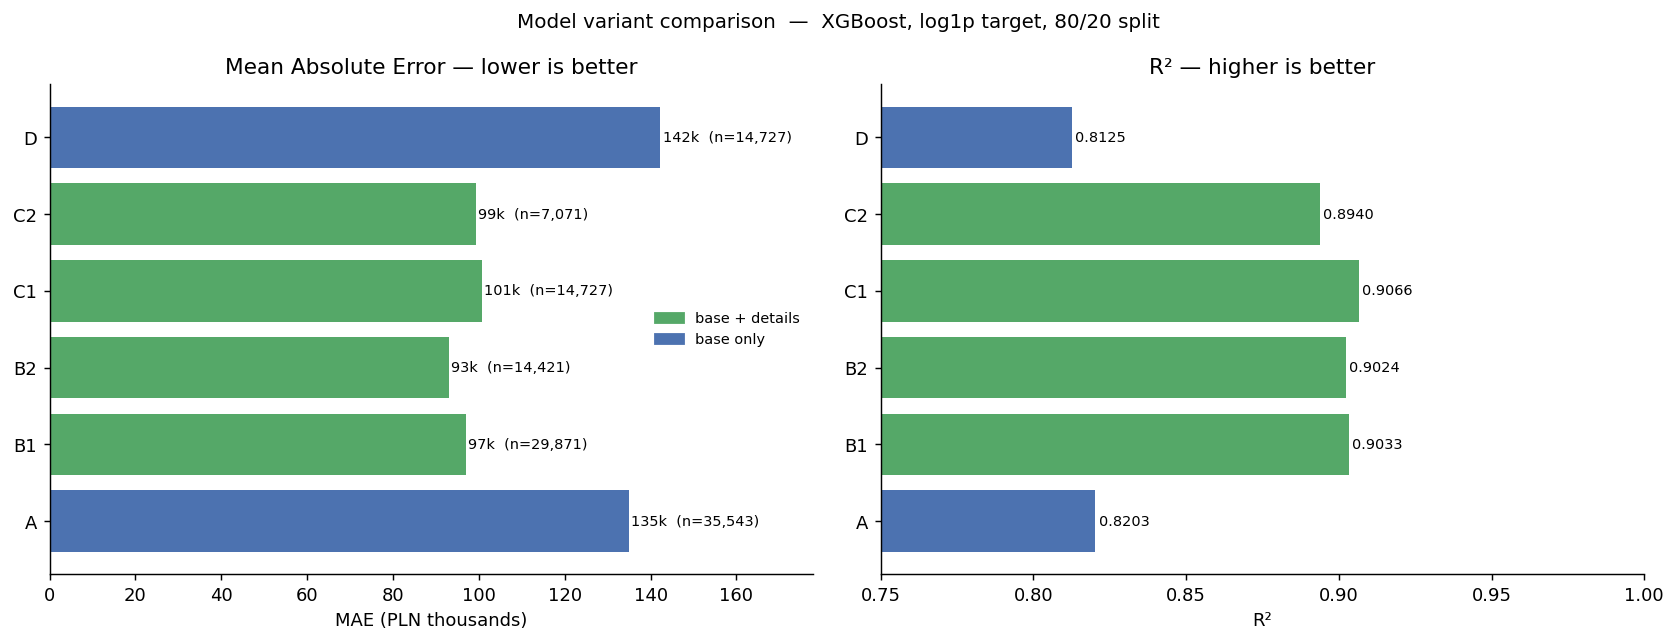

variant  rows     mae_pln     r2
      A 35543 134946.1207 0.8203
     B1 29871  96888.7367 0.9033
     B2 14421  93106.8269 0.9024
     C1 14727 100806.3391 0.9066
     C2  7071  99341.8545 0.8940
      D 14727 142278.9898 0.8125


In [14]:
summary = pd.DataFrame(results).T.reset_index().rename(columns={"index": "variant"})
summary["rows"] = [len(df_A), len(df_B1), len(df_B2), len(df_C1), len(df_C2), len(df_C1)]
summary = summary[["variant", "rows", "mae_pln", "r2"]]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = ["#4C72B0" if v in ("A", "D") else "#55A868" for v in summary["variant"]]

axes[0].barh(summary["variant"], summary["mae_pln"] / 1000, color=colors)
axes[0].set_xlabel("MAE (PLN thousands)")
axes[0].set_title("Mean Absolute Error — lower is better")
for i, (val, rows) in enumerate(zip(summary["mae_pln"], summary["rows"])):
    axes[0].text(val / 1000 + 0.5, i, f"{val/1000:.0f}k  (n={rows:,})", va="center", fontsize=8)
axes[0].set_xlim(0, summary["mae_pln"].max() / 1000 * 1.25)

axes[1].barh(summary["variant"], summary["r2"], color=colors)
axes[1].set_xlabel("R²")
axes[1].set_title("R² — higher is better")
for i, val in enumerate(summary["r2"]):
    axes[1].text(val + 0.001, i, f"{val:.4f}", va="center", fontsize=8)
axes[1].set_xlim(0.75, 1.0)

from matplotlib.patches import Patch
legend = [Patch(color="#55A868", label="base + details"), Patch(color="#4C72B0", label="base only")]
axes[0].legend(handles=legend, frameon=False, fontsize=8)

plt.suptitle("Model variant comparison  —  XGBoost, log1p target, 80/20 split", fontsize=11)
plt.tight_layout()
plt.show()

print(summary.to_string(index=False, float_format="{:.4f}".format))

## 12. Variant E — SHAP feature selection

100%|===================| 5964/5975 [05:58<00:00]       

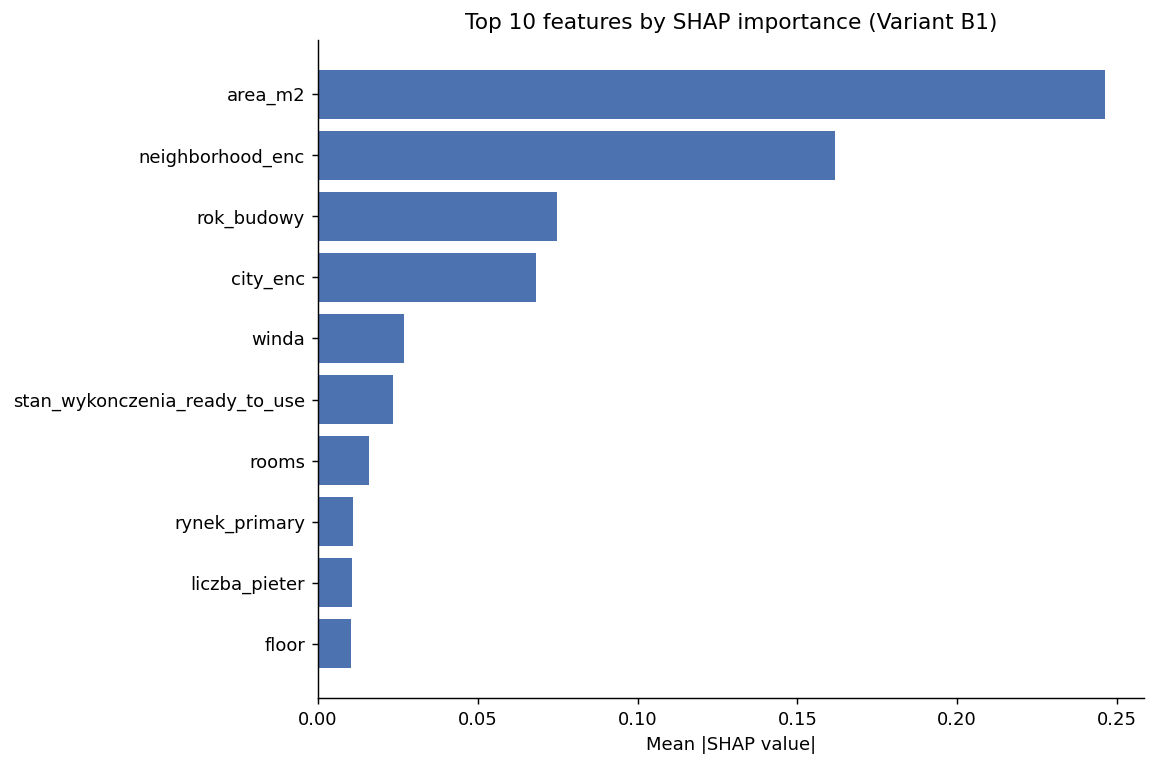

Top features selected for Variant E:
   1. area_m2                             0.2461
   2. neighborhood_enc                    0.1617
   3. rok_budowy                          0.0749
   4. city_enc                            0.0682
   5. winda                               0.0271
   6. stan_wykonczenia_ready_to_use       0.0234
   7. rooms                               0.0161
   8. rynek_primary                       0.0112
   9. liczba_pieter                       0.0108
  10. floor                               0.0105


In [15]:
explainer = shap.Explainer(models["B1"], X_tr_B1)
shap_values = explainer(X_va_B1)

mean_abs_shap = pd.Series(
    np.abs(shap_values.values).mean(axis=0),
    index=X_va_B1.columns,
).sort_values(ascending=False)

TOP_N = 10
top_features = mean_abs_shap.head(TOP_N).index.tolist()

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(mean_abs_shap.head(TOP_N).index[::-1], mean_abs_shap.head(TOP_N).values[::-1], color="#4C72B0")
ax.set_xlabel("Mean |SHAP value|")
ax.set_title(f"Top {TOP_N} features by SHAP importance (Variant B1)")
plt.tight_layout()
plt.show()

print("Top features selected for Variant E:")
for i, f in enumerate(top_features, 1):
    print(f"  {i:>2}. {f:<35} {mean_abs_shap[f]:.4f}")

### Learning curve — variant E

In [16]:
from sklearn.model_selection import StratifiedShuffleSplit

fractions = [0.15, 0.25, 0.40, 0.60, 0.80, 1.0]
results_E = []

df_B1_indexed = df_B1.copy()

for frac in fractions:
    if frac < 1.0:
        sss = StratifiedShuffleSplit(n_splits=1, test_size=1 - frac, random_state=SEED)
        idx, _ = next(sss.split(df_B1_indexed, df_B1_indexed["city"]))
        subset = df_B1_indexed.iloc[idx]
    else:
        subset = df_B1_indexed

    X_tr, X_va, y_tr, y_va = train_test_split(subset, subset[TARGET], test_size=0.2, random_state=SEED)
    X_tr_full, X_va_full = build_features(X_tr, X_va, use_details=True)

    X_tr_e = X_tr_full[top_features]
    X_va_e = X_va_full[top_features]

    _, metrics = train_xgb(X_tr_e, y_tr, X_va_e, y_va)
    results_E.append({"frac": frac, "rows": len(subset), **metrics})
    print(f"E frac={frac:.0%} | rows={len(subset):,} | MAE={metrics['mae_pln']:,.0f} PLN | R²={metrics['r2']:.4f}")

# Also store full E for final comparison
models["E"], results["E"] = train_xgb(
    df_B1_indexed[df_B1_indexed.index.isin(X_tr_full.index)].pipe(lambda _: X_tr_full[top_features]),
    y_tr,
    X_va_full[top_features],
    y_va,
)
results["E"] = results_E[-1]

df_E_curve = pd.DataFrame(results_E)
print("\n", df_E_curve[["rows", "mae_pln", "r2"]].to_string(index=False))

E frac=15% | rows=4,480 | MAE=114,844 PLN | R²=0.8769
E frac=25% | rows=7,467 | MAE=115,596 PLN | R²=0.8725
E frac=40% | rows=11,948 | MAE=108,980 PLN | R²=0.8672
E frac=60% | rows=17,922 | MAE=109,038 PLN | R²=0.8944
E frac=80% | rows=23,896 | MAE=100,287 PLN | R²=0.8983
E frac=100% | rows=29,871 | MAE=101,488 PLN | R²=0.8929

  rows   mae_pln   r2
 4480 114843.55 0.88
 7467 115595.67 0.87
11948 108980.01 0.87
17922 109038.44 0.89
23896 100287.18 0.90
29871 101488.31 0.89


## 13. Final comparison — all variants

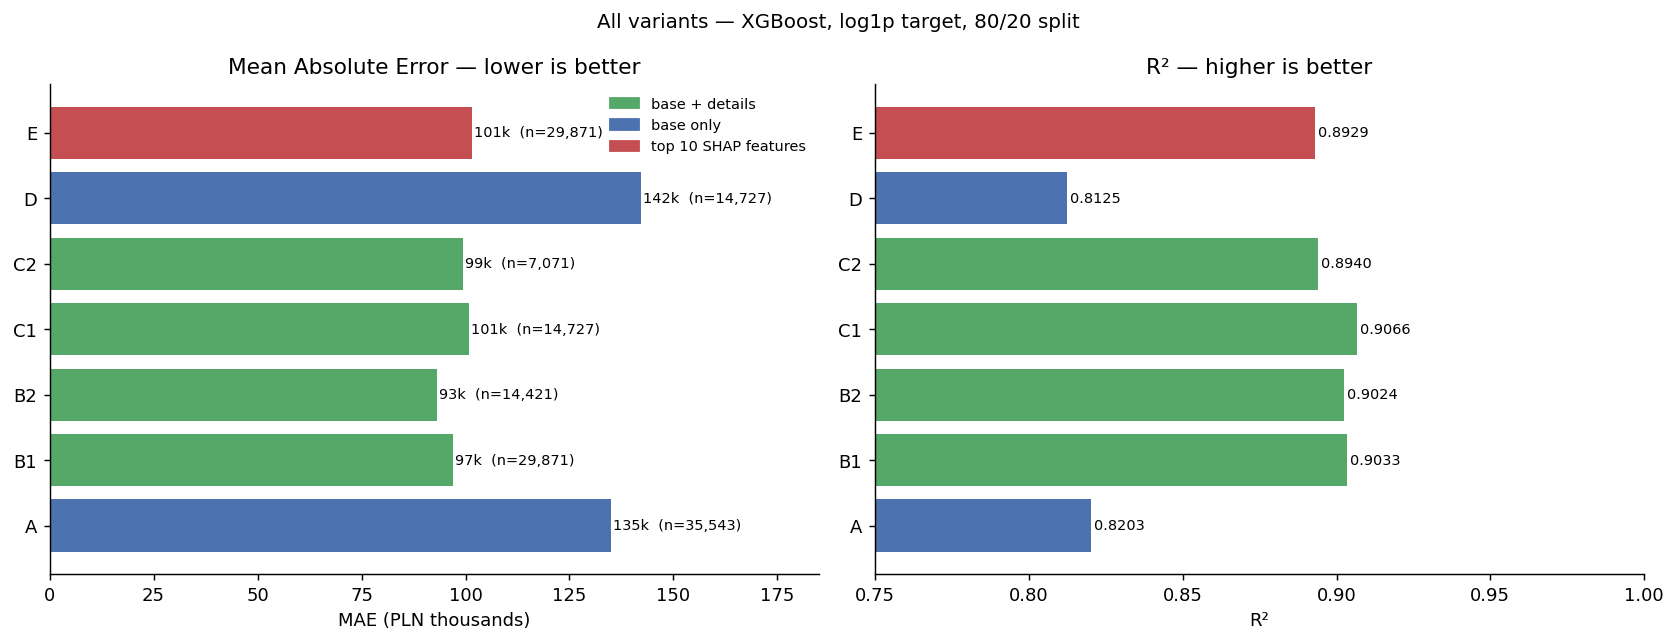

variant  rows     mae_pln     r2
      A 35543 134946.1207 0.8203
     B1 29871  96888.7367 0.9033
     B2 14421  93106.8269 0.9024
     C1 14727 100806.3391 0.9066
     C2  7071  99341.8545 0.8940
      D 14727 142278.9898 0.8125
      E 29871 101488.3078 0.8929


In [17]:
final = pd.DataFrame({
    "variant": ["A", "B1", "B2", "C1", "C2", "D", "E"],
    "rows":    [len(df_A), len(df_B1), len(df_B2), len(df_C1), len(df_C2), len(df_C1), len(df_B1)],
    "mae_pln": [results[v]["mae_pln"] for v in ["A", "B1", "B2", "C1", "C2", "D", "E"]],
    "r2":      [results[v]["r2"]      for v in ["A", "B1", "B2", "C1", "C2", "D", "E"]],
})

color_map = {"A": "#4C72B0", "D": "#4C72B0", "E": "#C44E52",
             "B1": "#55A868", "B2": "#55A868", "C1": "#55A868", "C2": "#55A868"}
colors = [color_map[v] for v in final["variant"]]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].barh(final["variant"], final["mae_pln"] / 1000, color=colors)
axes[0].set_xlabel("MAE (PLN thousands)")
axes[0].set_title("Mean Absolute Error — lower is better")
for i, (val, rows) in enumerate(zip(final["mae_pln"], final["rows"])):
    axes[0].text(val / 1000 + 0.5, i, f"{val/1000:.0f}k  (n={rows:,})", va="center", fontsize=8)
axes[0].set_xlim(0, final["mae_pln"].max() / 1000 * 1.3)

axes[1].barh(final["variant"], final["r2"], color=colors)
axes[1].set_xlabel("R²")
axes[1].set_title("R² — higher is better")
for i, val in enumerate(final["r2"]):
    axes[1].text(val + 0.001, i, f"{val:.4f}", va="center", fontsize=8)
axes[1].set_xlim(0.75, 1.0)

from matplotlib.patches import Patch
legend = [
    Patch(color="#55A868", label="base + details"),
    Patch(color="#4C72B0", label="base only"),
    Patch(color="#C44E52", label="top 10 SHAP features"),
]
axes[0].legend(handles=legend, frameon=False, fontsize=8)

plt.suptitle("All variants — XGBoost, log1p target, 80/20 split", fontsize=11)
plt.tight_layout()
plt.show()

print(final.to_string(index=False, float_format="{:.4f}".format))

## 14. Variant comparison summary.

| Variant | Rows | MAE PLN | R² |
|---|---|---|---|
| A | 35,543 | 134,946 | 0.820 |
| B1 | 29,871 | 96,889 | 0.903 |
| B2 | 14,421 | 93,107 | 0.902 |
| C1 | 14,727 | 100,806 | 0.907 |
| C2 | 7,071 | 99,342 | 0.894 |
| D | 14,727 | 142,279 | 0.813 |
| E | 29,871 | 101,488 | 0.893 |

**Do detail features help?**
Yes — significantly. C1 vs D (identical 15k rows): details reduce MAE by 42k PLN and lift R² from 0.813 to 0.907.

**Is more data better than richer features?**
No. B1 (30k rows, imputed) vs C1 (15k rows, imputed): doubling data gives only 4k PLN improvement.
Scraping details is more valuable than scraping more volume.

**Does dropping nulls beat imputation?**
Slightly. B2 (14k clean) beats B1 (30k imputed) by 3.8k PLN despite having half the rows.
When scraping details, it pays to filter listings with incomplete data.

**Does feature selection help?**
No. E (top 10 SHAP, 30k rows) scores 101k MAE vs B1's 97k — features outside top 10 still contribute collectively.

## 15. Final model — selective null strategy

In [18]:
# Drop only where high-SHAP detail columns are null
# rok_budowy (#3 SHAP) and stan_wykonczenia (#6 SHAP) — imputing these adds noise
# Everything else imputed — low signal, not worth losing rows

KEY_DETAIL_COLS = ["rok_budowy", "stan_wykonczenia"]
df_final = df[df["has_details"]].dropna(subset=KEY_DETAIL_COLS).copy()

X_tr, X_va, y_tr, y_va = train_test_split(df_final, df_final[TARGET], test_size=0.2, random_state=SEED)
X_tr, X_va = build_features(X_tr, X_va, use_details=True)
model_final, metrics_final = train_xgb(X_tr, y_tr, X_va, y_va)

print(f"rows={len(df_final):,} | MAE={metrics_final['mae_pln']:,.0f} PLN | R²={metrics_final['r2']:.4f}")

rows=26,305 | MAE=97,270 PLN | R²=0.9026


## 16. Error analysis by price segment

MAPE (mean):   11.2%
MAPE (median): 7.9%
MAE:           97,270 PLN

   bucket  count      mae  mape
    <300k    161  59478.9  30.4
 300-500k   1127  42867.1  10.2
 500-800k   2179  59516.6   9.2
800k-1.2M   1109 106710.0  11.0
 1.2-2.5M    580 242569.8  14.4
    >2.5M    105 620296.8  18.7


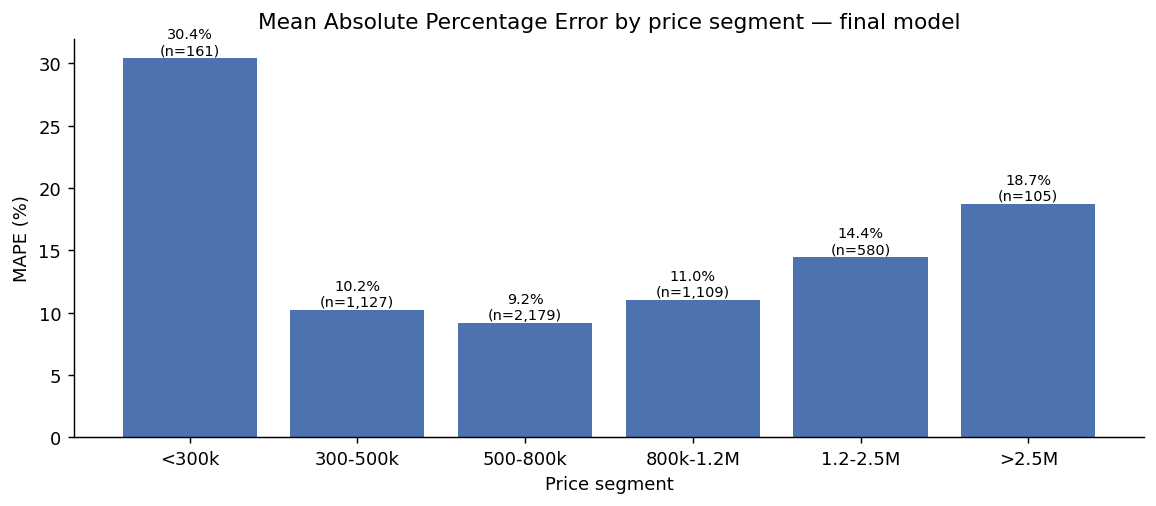

In [19]:
y_pred = np.expm1(model_final.predict(X_va))
y_true = np.expm1(y_va)

val_df = pd.DataFrame({
    "true":      y_true.values,
    "pred":      y_pred,
    "error":     np.abs(y_true.values - y_pred),
    "pct_error": np.abs(y_true.values - y_pred) / y_true.values * 100,
})

mape_mean   = val_df["pct_error"].mean()
mape_median = val_df["pct_error"].median()
print(f"MAPE (mean):   {mape_mean:.1f}%")
print(f"MAPE (median): {mape_median:.1f}%")
print(f"MAE:           {val_df['error'].mean():,.0f} PLN\n")

bins   = [0, 300_000, 500_000, 800_000, 1_200_000, 2_500_000, 999_999_999]
labels = ["<300k", "300-500k", "500-800k", "800k-1.2M", "1.2-2.5M", ">2.5M"]
val_df["bucket"] = pd.cut(val_df["true"], bins=bins, labels=labels)

bucket_stats = val_df.groupby("bucket", observed=True).agg(
    count=("true", "count"),
    mae=("error", "mean"),
    mape=("pct_error", "mean"),
).reset_index()
print(bucket_stats.to_string(index=False, float_format="{:.1f}".format))

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(bucket_stats["bucket"].astype(str), bucket_stats["mape"], color="#4C72B0")
ax.set_xlabel("Price segment")
ax.set_ylabel("MAPE (%)")
ax.set_title("Mean Absolute Percentage Error by price segment — final model")
for i, (mape_val, count) in enumerate(zip(bucket_stats["mape"], bucket_stats["count"])):
    ax.text(i, mape_val + 0.3, f"{mape_val:.1f}%\n(n={count:,})", ha="center", fontsize=8)
plt.tight_layout()
plt.show()

## 17. Conclusions

### Why this null strategy?
SHAP analysis on the full imputed model (B1) revealed that `rok_budowy` and
`stan_wykonczenia` are the 3rd and 6th most important features. Imputing these
with mode/median would replace a genuinely informative signal with noise —
a listing without a stated year of construction or finish standard is
fundamentally different from one that has it.

Columns outside the top 10 (`ogrzewanie`, `rodzaj_zabudowy`, `forma_wlasnosci`,
`okna`, `liczba_pieter`) carry weak individual signal. Dropping rows for their nulls
would sacrifice data volume for no meaningful quality gain, so they are imputed.

### Results vs other variants
| Variant | Rows | MAE PLN | R² | Null strategy |
|---|---|---|---|---|
| A | 35,543 | 134,946 | 0.820 | base only |
| B1 | 29,871 | 96,889 | 0.903 | all imputed |
| B2 | 14,421 | 93,107 | 0.902 | all null rows dropped |
| **Final** | **26,305** | **97,270** | **0.903** | **selective drop + impute** |
| D | 14,727 | 142,279 | 0.813 | base only, same rows as C1 |

### Honest interpretation
The selective strategy performs virtually identically to full imputation (B1) —
difference of ~400 PLN MAE is negligible. B2 (full drop) still has the best raw MAE
at 93k but on half the data.

In production this distinction matters less than it appears: with monthly scraping
and details collected at the same time as listings, null rates will be lower than
in the historical dataset (which mixed old and new scrapes). The selective drop
approach is adopted as it avoids imputing the two most predictive features.

### Final model metrics
| Metric | Value |
|---|---|
| Rows | 26,305 |
| MAE | 97,270 PLN |
| R² | 0.903 |
| MAPE (median) | 7.9% |
| MAPE (mean) | 11.2% |
| Best segment | 500–800k PLN (9.2% MAPE) |
| Worst segment | <300k PLN (30.4% MAPE, only 161 rows) |

### Key takeaways
- Detail features reduce MAE by ~45k PLN vs base-only on identical data (D: 142k → final: 97k)
- Scraping details is more valuable than scraping more volume without them
- Model works best in 300k–800k range — typical Polish apartment market
- Median MAPE 7.9% is competitive for listing-only data without transaction records or GPS coordinates
- <300k segment unreliable — too few training examples, consider excluding from app predictions